# EDA — dataset candidat `car-plate-detection` (pilier plaques)

**EDA** = *Exploratory Data Analysis*, analyse exploratoire des données : on regarde le dataset sous toutes ses coutures **avant** de décider quoi que ce soit (modèle, résolution d'entrée, découpage). C'est l'étape 1 du process `dl/AGENTS.md`.

**Dataset** : [`andrewmvd/car-plate-detection`](https://www.kaggle.com/datasets/andrewmvd/car-plate-detection) (Kaggle, licence CC0 — domaine public). 433 images de voitures, chacune accompagnée d'un fichier XML au format **PASCAL VOC** : un standard historique de la détection d'objets où chaque objet est décrit par une **boîte englobante** (*bounding box*) = un rectangle `(xmin, ymin, xmax, ymax)` en pixels.

**Objectif du pilier** : détecter les plaques d'immatriculation pour les **flouter** (besoin RGPD — Règlement Général sur la Protection des Données). Pas de lecture des caractères (pas d'OCR, *Optical Character Recognition*) : minimisation des données.

**Questions auxquelles cette EDA doit répondre** :
1. Volumes et résolutions — de quoi dispose-t-on ?
2. Nombre de plaques par image — le modèle doit-il gérer plusieurs boîtes ?
3. Taille des plaques (aire relative, largeur en pixels) — conditionne la résolution d'entrée du modèle et la taille des *ancres* (rectangles de référence que le détecteur ajuste).
4. Ratios d'aspect (largeur/hauteur des boîtes) — les plaques européennes « format long » (520×110 mm, ratio ≈ 4,7) ressemblent-elles à ce dataset ? C'est l'écart que la Phase 3 mesurera sur les vraies photos leboncoin.
5. Échantillon visuel — à quoi ressemblent les images et les annotations ?

**Contrôle d'intégrité déjà passé** (hors carnet) : 433 images ↔ 433 XML appariés, 0 erreur de parse, 471 boîtes toutes valides (`0 ≤ xmin < xmax ≤ largeur`), tailles déclarées dans les XML = tailles réelles des images.

In [1]:
from pathlib import Path

# defusedxml : même API que xml.etree de la stdlib, mais durci contre les XML malveillants
import defusedxml.ElementTree as ET
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

RAW = Path("../../data/plaques/raw")

# On construit deux tables :
#  - une ligne par IMAGE (dimensions, nombre de plaques)
#  - une ligne par BOÎTE (coordonnées, dimensions de la plaque)
lignes_images, lignes_boites = [], []
for xml in sorted(RAW.glob("annotations/*.xml")):
    racine = ET.parse(xml).getroot()
    nom = xml.stem  # ex. "Cars42"
    largeur = int(racine.findtext("size/width"))
    hauteur = int(racine.findtext("size/height"))
    objets = racine.findall("object")
    lignes_images.append({"nom": nom, "largeur": largeur, "hauteur": hauteur, "n_plaques": len(objets)})
    for obj in objets:
        b = obj.find("bndbox")
        xmin, ymin = int(b.findtext("xmin")), int(b.findtext("ymin"))
        xmax, ymax = int(b.findtext("xmax")), int(b.findtext("ymax"))
        lignes_boites.append({
            "nom": nom, "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax,
            "larg_plaque": xmax - xmin, "haut_plaque": ymax - ymin,
            "aire_relative": (xmax - xmin) * (ymax - ymin) / (largeur * hauteur),
            "ratio": (xmax - xmin) / (ymax - ymin),
        })

df_img = pd.DataFrame(lignes_images)
df_box = pd.DataFrame(lignes_boites)
print(f"{len(df_img)} images, {len(df_box)} boîtes (plaques annotées)")

433 images, 471 boîtes (plaques annotées)


## 1. Volumes et résolutions

La **résolution** (largeur × hauteur en pixels) compte double en détection : un réseau de neurones reçoit les images à une taille fixe ou bornée ; si les images sources sont petites, les plaques — déjà petites dans l'image — risquent de ne plus faire que quelques pixels après redimensionnement.

       largeur  hauteur
count    433.0    433.0
mean     425.0    292.0
std       68.0     66.0
min      225.0    141.0
25%      400.0    246.0
50%      400.0    270.0
75%      400.0    307.0
max      600.0    531.0

Résolutions les plus fréquentes :
400×300    64
400×267    50
400×225    47
590×350    10
400×268     9
600×450     9
400×266     8
400×299     8


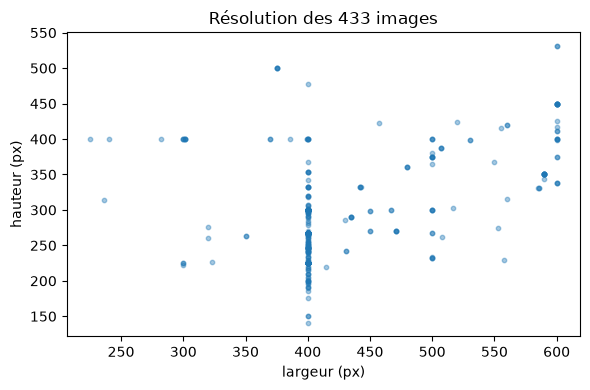

In [2]:
print(df_img[["largeur", "hauteur"]].describe().round(0).to_string())
print("\nRésolutions les plus fréquentes :")
print((df_img["largeur"].astype(str) + "×" + df_img["hauteur"].astype(str)).value_counts().head(8).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df_img["largeur"], df_img["hauteur"], s=10, alpha=0.4)
ax.set_xlabel("largeur (px)"); ax.set_ylabel("hauteur (px)")
ax.set_title("Résolution des 433 images")
plt.tight_layout(); plt.show()

## 2. Nombre de plaques par image

Si certaines images contiennent plusieurs plaques, le modèle doit produire un **nombre variable de boîtes** par image — c'est le format natif des détecteurs (par opposition à un modèle qui prédirait une seule boîte fixe). Ça impose aussi le format de données `{"boxes": [N, 4]}` prévu en Phase 2.

In [3]:
repartition = df_img["n_plaques"].value_counts().sort_index()
print("plaques/image  nb d'images")
print(repartition.to_string())
part_multi = (df_img["n_plaques"] > 1).mean()
print(f"\nImages multi-plaques : {part_multi:.1%}")

plaques/image  nb d'images
n_plaques
1    409
2     18
4      5
6      1

Images multi-plaques : 5.5%


## 3. Taille des plaques

Deux mesures complémentaires :
- **aire relative** = surface de la boîte / surface de l'image. En détection, un objet sous ~1 % de l'image est considéré « petit » — c'est le régime le plus difficile.
- **largeur en pixels** : en dessous de ~30 px de large, une plaque redimensionnée devient difficile à localiser précisément. Cette mesure conditionne la résolution d'entrée qu'on choisira en Phase 2.

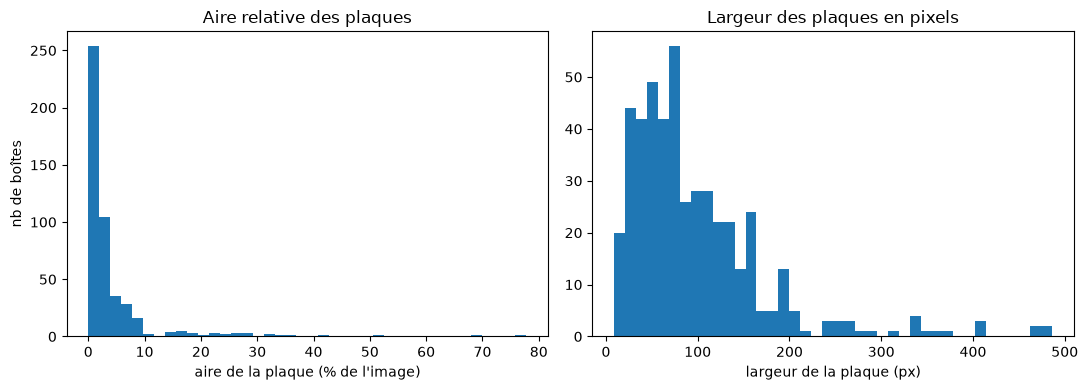

       aire_relative  larg_plaque  haut_plaque
count        471.000      471.000      471.000
mean           0.041       97.788       35.176
std            0.076       76.419       29.721
min            0.000        9.000        5.000
25%            0.008       47.500       19.000
50%            0.018       76.000       27.000
75%            0.038      128.000       39.500
max            0.778      486.000      240.000

Boîtes sous 1 % de l'image : 30.1%
Boîtes de moins de 30 px de large : 11.3%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_box["aire_relative"] * 100, bins=40)
axes[0].set_xlabel("aire de la plaque (% de l'image)"); axes[0].set_ylabel("nb de boîtes")
axes[0].set_title("Aire relative des plaques")
axes[1].hist(df_box["larg_plaque"], bins=40)
axes[1].set_xlabel("largeur de la plaque (px)")
axes[1].set_title("Largeur des plaques en pixels")
plt.tight_layout(); plt.show()

print(df_box[["aire_relative", "larg_plaque", "haut_plaque"]].describe().round(3).to_string())
print(f"\nBoîtes sous 1 % de l'image : {(df_box['aire_relative'] < 0.01).mean():.1%}")
print(f"Boîtes de moins de 30 px de large : {(df_box['larg_plaque'] < 30).mean():.1%}")

## 4. Ratios d'aspect

Le **ratio d'aspect** = largeur / hauteur de la boîte. Les plaques européennes « format long » font 520×110 mm → ratio ≈ 4,7 (vu de face ; la perspective le réduit). Les plaques américaines (305×152 mm) tournent autour de 2, les plaques carrées autour de 1. Ce dataset est international : si les ratios s'écartent du format européen, le modèle appris ici pourrait être moins à l'aise sur les photos françaises — c'est exactement l'écart que la **Phase 3** mesurera sur le lot leboncoin.

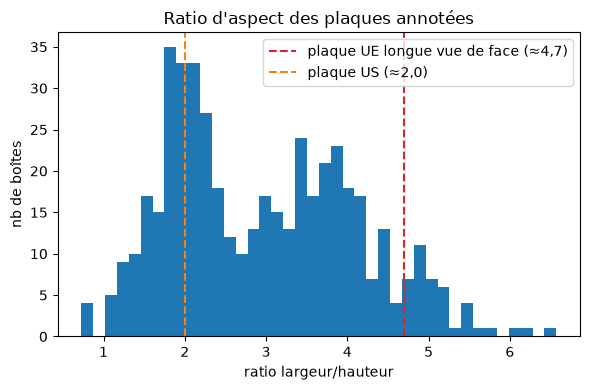

count    471.00
mean       2.96
std        1.14
min        0.73
25%        2.00
50%        2.86
75%        3.84
max        6.57

Boîtes de ratio ≥ 3 (allure « format UE long ») : 47.6%
Boîtes de ratio < 2 (allure carrée/US) : 23.8%


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_box["ratio"], bins=40)
ax.axvline(4.7, color="tab:red", linestyle="--", label="plaque UE longue vue de face (≈4,7)")
ax.axvline(2.0, color="tab:orange", linestyle="--", label="plaque US (≈2,0)")
ax.set_xlabel("ratio largeur/hauteur"); ax.set_ylabel("nb de boîtes")
ax.set_title("Ratio d'aspect des plaques annotées")
ax.legend()
plt.tight_layout(); plt.show()

print(df_box["ratio"].describe().round(2).to_string())
print(f"\nBoîtes de ratio ≥ 3 (allure « format UE long ») : {(df_box['ratio'] >= 3).mean():.1%}")
print(f"Boîtes de ratio < 2 (allure carrée/US) : {(df_box['ratio'] < 2).mean():.1%}")

## 5. Échantillon visuel

20 images tirées régulièrement dans le dataset (pas au hasard : reproductible sans graine aléatoire), avec les boîtes annotées en rouge. On y jauge à l'œil : type de scène (voiture seule, trafic, parking), pays des plaques, qualité des annotations.

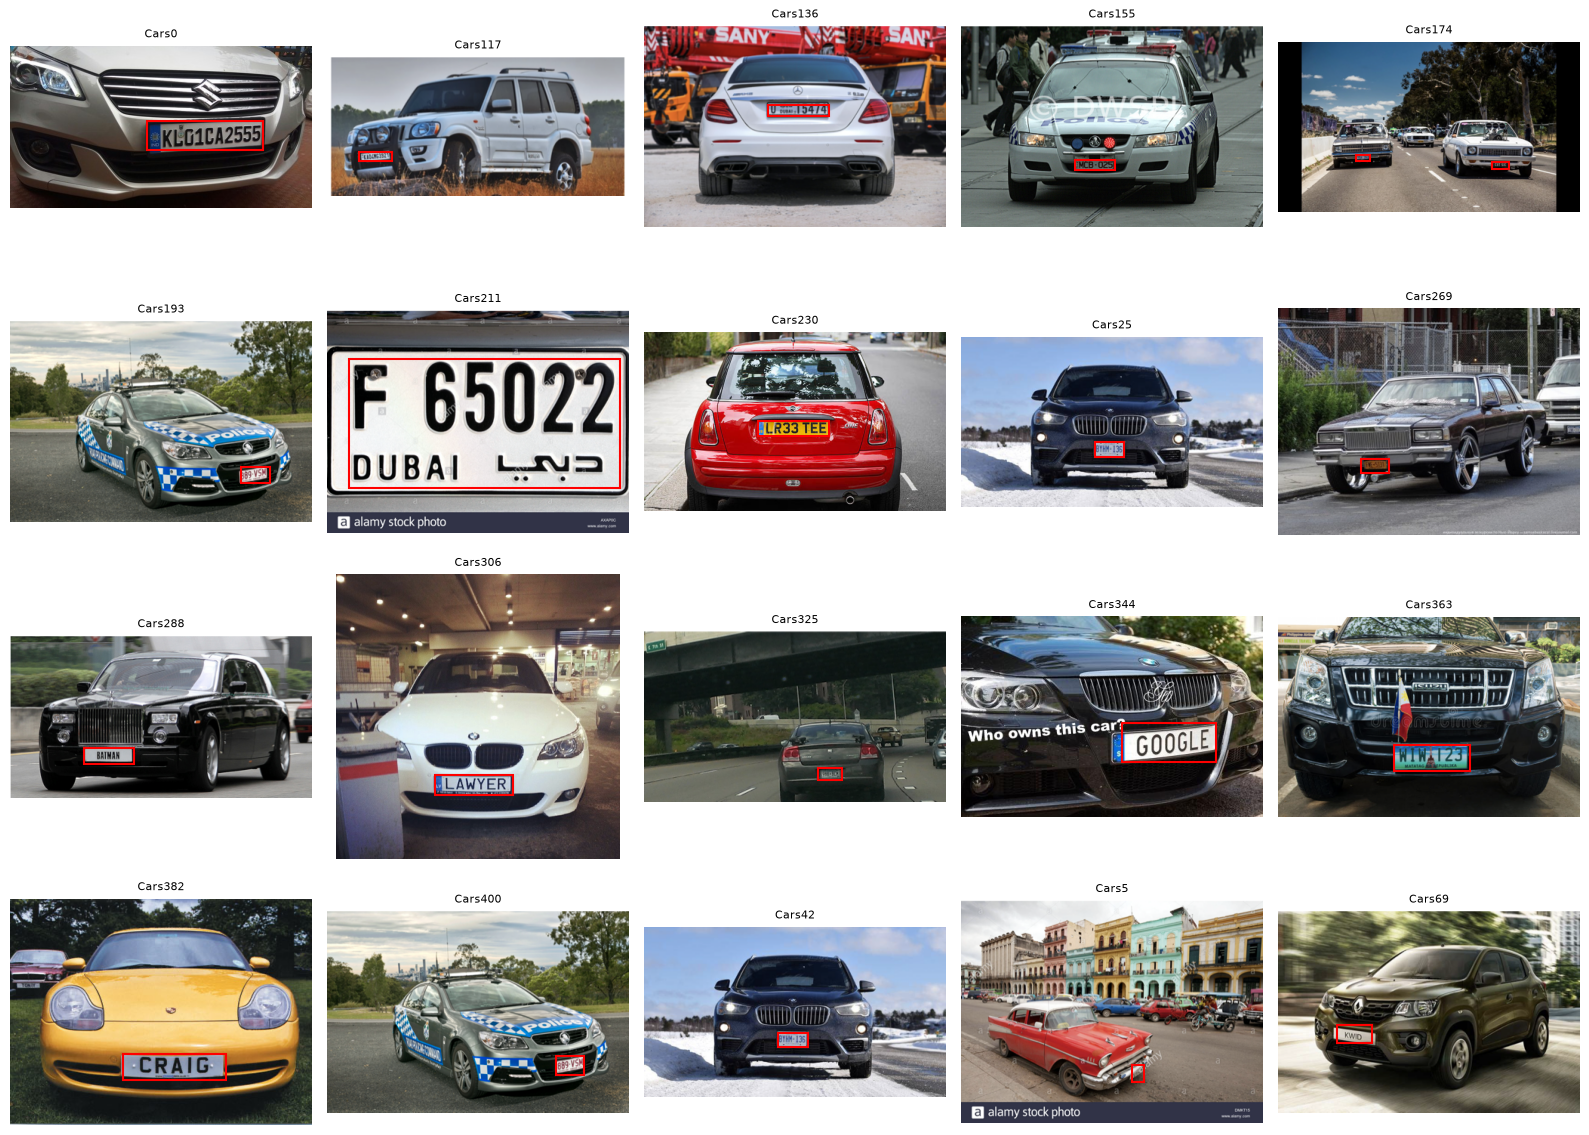

In [6]:
from matplotlib.patches import Rectangle

noms = df_img["nom"].sort_values().tolist()
echantillon = noms[:: max(1, len(noms) // 20)][:20]

fig, axes = plt.subplots(4, 5, figsize=(16, 12))
for ax, nom in zip(axes.flat, echantillon):
    img = Image.open(RAW / "images" / f"{nom}.png")
    ax.imshow(img)
    for _, b in df_box[df_box["nom"] == nom].iterrows():
        ax.add_patch(Rectangle((b.xmin, b.ymin), b.larg_plaque, b.haut_plaque,
                               fill=False, edgecolor="red", linewidth=1.5))
    ax.set_title(nom, fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Limites du dataset et résumé

**Limite structurelle consignée** : le dataset ne documente **pas l'identité des voitures** (aucun champ « même véhicule vu sous plusieurs angles »). On ne peut donc pas garantir un découpage train/validation « sans la même voiture des deux côtés » (règle anti-*data leakage* de `dl/AGENTS.md`). Décision par défaut : **split par image**, limite documentée. Le vrai juge de paix reste la Phase 3 : mesure sur les photos leboncoin, jamais vues à l'entraînement.

**Autre limite attendue** : dataset international (plaques indiennes, européennes, etc.) → l'écart avec les plaques françaises sera mesuré en Phase 3, pas présumé ici.

In [7]:
print("=== RÉSUMÉ CHIFFRÉ — dataset car-plate-detection ===")
print(f"Images : {len(df_img)} | Boîtes : {len(df_box)}")
print(f"Résolution médiane : {df_img['largeur'].median():.0f}×{df_img['hauteur'].median():.0f} px")
print(f"Plaques/image : min {df_img['n_plaques'].min()}, médiane {df_img['n_plaques'].median():.0f}, max {df_img['n_plaques'].max()} | multi-plaques : {(df_img['n_plaques'] > 1).mean():.1%}")
print(f"Aire relative médiane : {df_box['aire_relative'].median():.2%} | < 1 % de l'image : {(df_box['aire_relative'] < 0.01).mean():.1%}")
print(f"Largeur plaque médiane : {df_box['larg_plaque'].median():.0f} px | < 30 px : {(df_box['larg_plaque'] < 30).mean():.1%}")
print(f"Ratio d'aspect médian : {df_box['ratio'].median():.2f} | ≥ 3 (UE long) : {(df_box['ratio'] >= 3).mean():.1%}")
print("Split : par image (identité voiture non documentée — limite consignée)")

=== RÉSUMÉ CHIFFRÉ — dataset car-plate-detection ===
Images : 433 | Boîtes : 471
Résolution médiane : 400×270 px
Plaques/image : min 1, médiane 1, max 6 | multi-plaques : 5.5%
Aire relative médiane : 1.83% | < 1 % de l'image : 30.1%
Largeur plaque médiane : 76 px | < 30 px : 11.3%
Ratio d'aspect médian : 2.86 | ≥ 3 (UE long) : 47.6%
Split : par image (identité voiture non documentée — limite consignée)
